# 03 — Feature Engineering

Creates a compact set of price-based features and a stationary candidate series for the modeling stage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.stattools import adfuller

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "petr4_daily.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "petr4_features.csv"

if not RAW_PATH.exists():
    raise FileNotFoundError("Raw data not found. Run 01_data_collection.ipynb first.")

df_raw = pd.read_csv(RAW_PATH, parse_dates=["Date"], index_col="Date").sort_index()
df_raw.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2021-07-21,26.790001,27.240000,26.590000,26.959999,7.760904,51116600,0.0,0.0
2021-07-22,27.000000,27.219999,26.709999,26.900000,7.743631,37736500,0.0,0.0
2021-07-23,27.100000,27.170000,26.680000,26.740000,7.697572,34025500,0.0,0.0
2021-07-26,26.740000,27.469999,26.719999,27.469999,7.907716,46802600,0.0,0.0
2021-07-27,27.350000,27.400000,26.900000,27.150000,7.815598,51901800,0.0,0.0


## Feature creation

The features preserve the original analysis while using returns for the volatility estimate.

In [2]:
market_columns = [
    column for column in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    if column in df_raw.columns
]
df_features = df_raw[market_columns].copy()

df_features["Return"] = df_features["Close"].pct_change()
df_features["Volatility_5"] = (
    df_features["Return"].rolling(5).std() * np.sqrt(252)
)
df_features["Rolling_Mean_10"] = df_features["Close"].rolling(10).mean()
df_features["Close_diff"] = df_features["Close"].diff()

df_features.tail()

,Open,High,Low,Close,Adj Close,Volume,Return,Volatility_5,Rolling_Mean_10,Close_diff
Date,,,,,,,,,,
2026-07-15,40.410000,40.799999,40.230000,40.590000,40.590000,25608800,-0.001722,0.222653,39.284,-0.070000
2026-07-16,40.380001,40.860001,39.889999,39.889999,39.889999,20551700,-0.017246,0.252539,39.477,-0.700001
2026-07-17,40.410000,41.110001,40.410000,40.900002,40.900002,32168300,0.025320,0.295684,39.742,1.010002
2026-07-20,41.200001,41.439999,40.470001,41.150002,41.150002,26987600,0.006112,0.244353,40.080,0.250000
2026-07-21,41.209999,41.700001,41.130001,41.660000,41.660000,38572100,0.012394,0.252105,40.402,0.509998


## Stationarity check

The Augmented Dickey–Fuller test compares the closing price with its first difference. A p-value below 0.05 indicates evidence against a unit root.

In [3]:
def adf_summary(series: pd.Series, name: str) -> dict:
    statistic, p_value, used_lags, observations, *_ = adfuller(series.dropna())
    return {
        "series": name,
        "adf_statistic": statistic,
        "p_value": p_value,
        "used_lags": used_lags,
        "observations": observations,
        "stationary_at_5pct": p_value < 0.05,
    }

adf_results = pd.DataFrame([
    adf_summary(df_features["Close"], "Close"),
    adf_summary(df_features["Close_diff"], "Close_diff"),
]).set_index("series")

display(adf_results.round(4))

,adf_statistic,p_value,used_lags,observations,stationary_at_5pct
series,,,,,
Close,-2.151,0.2245,0,1247,False
Close_diff,-34.573,0.0000,0,1246,True


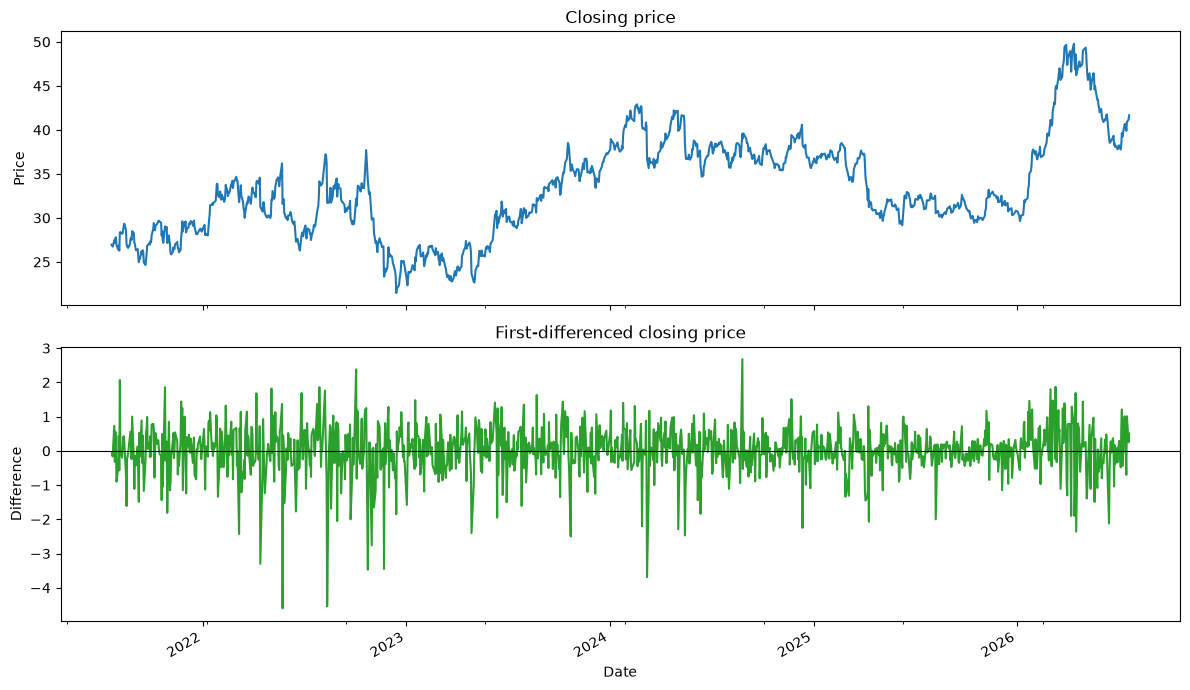

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
df_features["Close"].plot(ax=axes[0], color="tab:blue")
axes[0].set(title="Closing price", ylabel="Price")

df_features["Close_diff"].plot(ax=axes[1], color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="First-differenced closing price", xlabel="Date", ylabel="Difference")

plt.tight_layout()
plt.show()

## Save processed data

Rows made incomplete by rolling windows or differencing are removed only after all features have been created.

In [6]:
feature_columns = ["Return", "Volatility_5", "Rolling_Mean_10", "Close_diff"]
df_features = df_features.dropna(subset=feature_columns)

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df_features.to_csv(PROCESSED_PATH)
print(f"Final shape: {df_features.shape}")

Final shape: (1239, 10)


## Output features

- `Return`: daily percentage change in the closing price.
- `Volatility_5`: five-session rolling return volatility, annualized with 252 trading sessions.
- `Rolling_Mean_10`: ten-session moving average of the closing price.
- `Close_diff`: first difference used as the stationary candidate for ARIMA modeling.